<a href="https://colab.research.google.com/github/NerminWEST/Kaggle_Dataset_Fish_Model1.0/blob/main/B_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# MARINA PLUS - Behavior Detection Model Training (Model #5)
# Dual-Stream Network: Global Motion + Per-Fish Tracking
# ============================================================================

# %% [markdown]
# # 🐟 MARINA PLUS - Behavior Detection System (Model #5)
#
# ## What This Model Does
#
# Detects and classifies tuna behavior into actionable categories:
#
# **School-Level Behaviors:**
# 1. **Feeding Frenzy** - Active feeding, high energy
# 2. **Normal Swimming** - Regular schooling behavior
# 3. **Fright/Escape** - Stress response, rapid movement
# 4. **Hypoxia** - Surface gasping, low oxygen
# 5. **Starvation** - Low energy, weak swimming
#
# **Per-Fish Behaviors:**
# - Individual feeding attempts
# - Escape movements
# - Surface gasping
# - Passive/idle state
# - Continuous fatigue
#
# **Architecture:**
# ```
# Video Stream
#     ↓
# ├─→ Global Motion Stream (Optical Flow)
# │   └─→ School-Level CNN → Behavior Class
# │
# └─→ Per-Fish Tracking Stream (SORT + Features)
#     └─→ LSTM → Individual Behavior
# ```

# %% [markdown]
# ## 📦 Step 1: Setup Environment

# %%
# Check if running on Colab
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("✓ Running on Google Colab")
else:
    print("✓ Running on Local Jupyter")


✓ Running on Google Colab


In [ ]:
# %%
# Install required packages
!pip install torch torchvision opencv-python-headless numpy matplotlib seaborn scikit-learn tqdm filterpy ultralytics -q

# %%
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import cv2
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tqdm.auto import tqdm
import time
from collections import deque
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.83 GB


In [ ]:
# %% [markdown]
# ## 💾 Step 2: Mount Google Drive & Setup Paths

# %%
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted!")

    # Paths
    DATASET_PATH = '/content/drive/MyDrive/TunaDataset'
    YOLO_MODEL_PATH = '/content/drive/MyDrive/marina_plus_models/yolov8n_tuna_best.pt'
    SAVE_PATH = '/content/drive/MyDrive/marina_plus_models'

    # Copy to local for faster access
    LOCAL_DATASET_PATH = '/content/TunaDataset'

    import shutil
    if Path(DATASET_PATH).exists() and not Path(LOCAL_DATASET_PATH).exists():
        print("Copying dataset to local storage...")
        shutil.copytree(DATASET_PATH, LOCAL_DATASET_PATH)
        print("✓ Dataset copied")
else:
    # Local paths
    LOCAL_DATASET_PATH = './TunaDataset'
    YOLO_MODEL_PATH = './marina_plus/yolov8n_tuna/weights/best.pt'
    SAVE_PATH = './marina_plus_models'

print(f"\n📁 Paths configured:")
print(f"  Dataset: {LOCAL_DATASET_PATH}")
print(f"  YOLOv8: {YOLO_MODEL_PATH}")
print(f"  Save: {SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted!

📁 Paths configured:
  Dataset: /content/TunaDataset
  YOLOv8: /content/drive/MyDrive/marina_plus_models/yolov8n_tuna_best.pt
  Save: /content/drive/MyDrive/marina_plus_models


In [ ]:
# %% [markdown]
# ## 🎬 Step 3: Video Processing & Feature Extraction

# %%
class VideoFeatureExtractor:
    """
    Extract motion and tracking features from videos
    """

    def __init__(self, yolo_model_path):
        from ultralytics import YOLO
        self.yolo = YOLO(yolo_model_path)
        print("✓ YOLOv8 model loaded for tracking")

    def extract_optical_flow(self, frame1, frame2):
        """
        Extract dense optical flow between consecutive frames
        """
        gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

        # Farneback optical flow
        flow = cv2.calcOpticalFlowFarneback(
            gray1, gray2, None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )

        # Calculate magnitude and angle
        magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

        return flow, magnitude, angle

    def compute_motion_features(self, magnitude, angle):
        """
        Compute global motion statistics
        """
        features = {
            'mean_magnitude': magnitude.mean(),
            'max_magnitude': magnitude.max(),
            'std_magnitude': magnitude.std(),
            'median_magnitude': np.median(magnitude),
            'motion_energy': (magnitude ** 2).sum(),
            'dominant_direction': np.median(angle),
            'direction_variance': angle.std(),
            'active_pixels_ratio': (magnitude > 1.0).sum() / magnitude.size
        }

        return features

    def detect_and_track(self, frame):
        """
        Detect fish and return tracking information
        """
        results = self.yolo.predict(frame, conf=0.3, verbose=False)

        detections = []
        if len(results[0].boxes) > 0:
            for box in results[0].boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = box.conf[0].cpu().numpy()

                # Calculate bbox features
                width = x2 - x1
                height = y2 - y1
                area = width * height
                aspect_ratio = width / (height + 1e-6)
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2

                detections.append({
                    'bbox': [x1, y1, x2, y2],
                    'confidence': conf,
                    'center': [center_x, center_y],
                    'area': area,
                    'aspect_ratio': aspect_ratio
                })

        return detections

    def extract_per_fish_features(self, detection, prev_detection=None):
        """
        Extract features for individual fish
        """
        features = {
            'area': detection['area'],
            'aspect_ratio': detection['aspect_ratio'],
            'confidence': detection['confidence']
        }

        # Motion features (if previous detection available)
        if prev_detection is not None:
            dx = detection['center'][0] - prev_detection['center'][0]
            dy = detection['center'][1] - prev_detection['center'][1]

            velocity = np.sqrt(dx**2 + dy**2)
            direction = np.arctan2(dy, dx)

            features['velocity'] = velocity
            features['direction'] = direction
            features['area_change'] = detection['area'] - prev_detection['area']
        else:
            features['velocity'] = 0.0
            features['direction'] = 0.0
            features['area_change'] = 0.0

        return features

# %%
# Initialize feature extractor
if Path(YOLO_MODEL_PATH).exists():
    feature_extractor = VideoFeatureExtractor(YOLO_MODEL_PATH)
else:
    print("⚠️  YOLOv8 model not found. Please train Model #1 first.")
    print("   For now, we'll create a dummy extractor for demonstration.")

# %% [markdown]
# ## 📊 Step 4: Dataset Creation & Annotation

# %%
class BehaviorDataset(Dataset):
    """
    Dataset for behavior recognition
    Supports both video sequences and pre-extracted features
    """

    def __init__(self, data_path, split='train', sequence_length=30, transform=None):
        self.data_path = Path(data_path)
        self.split = split
        self.sequence_length = sequence_length
        self.transform = transform

        # School-level behavior classes
        self.school_classes = [
            'FEEDING',
            'NORMAL',
            'FRIGHT',
            'HYPOXIA',
            'STARVATION'
        ]

        # Per-fish behavior classes
        self.fish_classes = [
            'FEEDING_ATTEMPT',
            'ESCAPE',
            'PASSIVE',
            'SURFACE_GASP',
            'FATIGUE'
        ]

        # Load annotations
        self.samples = self._load_annotations()

        print(f"{split} set: {len(self.samples)} sequences")

    def _load_annotations(self):
        """
        Load behavior annotations

        Expected format:
        behavior_annotations/
        ├── train/
        │   ├── video1_annotations.json
        │   ├── video2_annotations.json
        │   └── ...
        """
        annotation_path = self.data_path / 'behavior_annotations' / self.split

        if not annotation_path.exists():
            print(f"⚠️  Annotation path not found: {annotation_path}")
            print("   Creating synthetic annotations for demonstration...")
            return self._create_synthetic_annotations()

        samples = []
        for json_file in annotation_path.glob('*.json'):
            with open(json_file, 'r') as f:
                data = json.load(f)
                samples.extend(data['sequences'])

        return samples

    def _create_synthetic_annotations(self):
        """
        Create synthetic annotations for demonstration
        In production, use real annotated data
        """
        samples = []

        # Generate 1000 synthetic sequences
        for i in range(1000):
            # Random school behavior
            school_behavior = np.random.choice(self.school_classes)

            # Generate sequence of motion features
            motion_features = np.random.randn(self.sequence_length, 8)

            samples.append({
                'id': f'synthetic_{i}',
                'school_behavior': school_behavior,
                'motion_features': motion_features.tolist()
            })

        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Motion features (for school-level)
        motion_features = torch.tensor(
            sample['motion_features'],
            dtype=torch.float32
        )

        # School behavior label
        school_label = self.school_classes.index(sample['school_behavior'])

        return {
            'motion_features': motion_features,
            'school_label': torch.tensor(school_label, dtype=torch.long)
        }

# %%
# Create datasets
print("📊 Creating behavior datasets...")

train_dataset = BehaviorDataset(
    LOCAL_DATASET_PATH,
    split='train',
    sequence_length=30
)

valid_dataset = BehaviorDataset(
    LOCAL_DATASET_PATH,
    split='valid',
    sequence_length=30
)

test_dataset = BehaviorDataset(
    LOCAL_DATASET_PATH,
    split='test',
    sequence_length=30
)

# Create dataloaders
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\n✓ Dataloaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")
print(f"  Test batches: {len(test_loader)}")


✓ YOLOv8 model loaded for tracking
📊 Creating behavior datasets...
⚠️  Annotation path not found: /content/TunaDataset/behavior_annotations/train
   Creating synthetic annotations for demonstration...
train set: 1000 sequences
⚠️  Annotation path not found: /content/TunaDataset/behavior_annotations/valid
   Creating synthetic annotations for demonstration...
valid set: 1000 sequences
⚠️  Annotation path not found: /content/TunaDataset/behavior_annotations/test
   Creating synthetic annotations for demonstration...
test set: 1000 sequences

✓ Dataloaders created:
  Train batches: 63
  Valid batches: 63
  Test batches: 63


In [ ]:
# %% [markdown]
# ## 🏗️ Step 5: Model Architecture

# %%
class SchoolBehaviorCNN(nn.Module):
    """
    School-level behavior recognition from global motion features
    Uses 1D CNN for temporal feature processing
    """

    def __init__(self, input_features=8, num_classes=5, sequence_length=30):
        super(SchoolBehaviorCNN, self).__init__()

        # 1D Convolutional layers for temporal processing
        self.conv1 = nn.Sequential(
            nn.Conv1d(input_features, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: (batch, sequence_length, features)
        # Transpose for 1D conv: (batch, features, sequence_length)
        x = x.transpose(1, 2)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Classify
        x = self.fc(x)

        return x


class PerFishBehaviorLSTM(nn.Module):
    """
    Per-fish behavior recognition using LSTM
    Processes temporal sequence of fish features
    """

    def __init__(self, input_features=7, hidden_size=64, num_classes=5, num_layers=2):
        super(PerFishBehaviorLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layers
        self.lstm = nn.LSTM(
            input_features,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0
        )

        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
            nn.Softmax(dim=1)
        )

        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: (batch, sequence_length, features)

        # LSTM forward
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch, sequence_length, hidden_size)

        # Apply attention
        attention_weights = self.attention(lstm_out)
        # attention_weights shape: (batch, sequence_length, 1)

        # Weighted sum
        context = torch.sum(lstm_out * attention_weights, dim=1)
        # context shape: (batch, hidden_size)

        # Classify
        output = self.fc(context)

        return output


class DualStreamBehaviorModel(nn.Module):
    """
    Complete dual-stream behavior recognition model
    Combines school-level CNN and per-fish LSTM
    """

    def __init__(self,
                 motion_features=8,
                 fish_features=7,
                 school_classes=5,
                 fish_classes=5,
                 sequence_length=30):
        super(DualStreamBehaviorModel, self).__init__()

        # School-level stream
        self.school_stream = SchoolBehaviorCNN(
            input_features=motion_features,
            num_classes=school_classes,
            sequence_length=sequence_length
        )

        # Per-fish stream
        self.fish_stream = PerFishBehaviorLSTM(
            input_features=fish_features,
            hidden_size=64,
            num_classes=fish_classes,
            num_layers=2
        )

    def forward(self, motion_features, fish_features=None):
        # School-level prediction
        school_output = self.school_stream(motion_features)

        # Per-fish prediction (if features provided)
        fish_output = None
        if fish_features is not None:
            fish_output = self.fish_stream(fish_features)

        return school_output, fish_output

# %%
# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = DualStreamBehaviorModel(
    motion_features=8,
    fish_features=7,
    school_classes=5,
    fish_classes=5,
    sequence_length=30
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model created:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  School classes: {train_dataset.school_classes}")
print(f"  Fish classes: {train_dataset.fish_classes}")


Using device: cuda

✓ Model created:
  Total parameters: 169,707
  Trainable parameters: 169,707
  School classes: ['FEEDING', 'NORMAL', 'FRIGHT', 'HYPOXIA', 'STARVATION']
  Fish classes: ['FEEDING_ATTEMPT', 'ESCAPE', 'PASSIVE', 'SURFACE_GASP', 'FATIGUE']


📋 Training Configuration:
  Epochs: 50
  Batch size: 16
  Learning rate: 0.001
  Weight decay: 0.0001
  Loss: CrossEntropyLoss
  Optimizer: Adam
  Scheduler: ReduceLROnPlateau

STARTING TRAINING

Epoch 1/50
----------------------------------------------------------------------


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Validation:   0%|          | 0/63 [00:00<?, ?it/s]


Epoch 1 Summary:
  Train Loss: 1.6198 | Train Acc: 19.20%
  Val Loss: 1.6103 | Val Acc: 22.20%
  Learning Rate: 0.001000
  ✓ Best model saved! (Val Acc: 22.20%)

Epoch 2/50
----------------------------------------------------------------------


Training:   0%|          | 0/63 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/63 [00:00<?, ?it/s]


Epoch 49 Summary:
  Train Loss: 0.0302 | Train Acc: 99.50%
  Val Loss: 5.1529 | Val Acc: 19.70%
  Learning Rate: 0.000004

Epoch 50/50
----------------------------------------------------------------------


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Validation:   0%|          | 0/63 [00:40<?, ?it/s]


Epoch 50 Summary:
  Train Loss: 0.0389 | Train Acc: 99.20%
  Val Loss: 5.1228 | Val Acc: 20.20%
  Learning Rate: 0.000004

✓ Training completed in 15.87 minutes
  Best validation accuracy: 22.20%


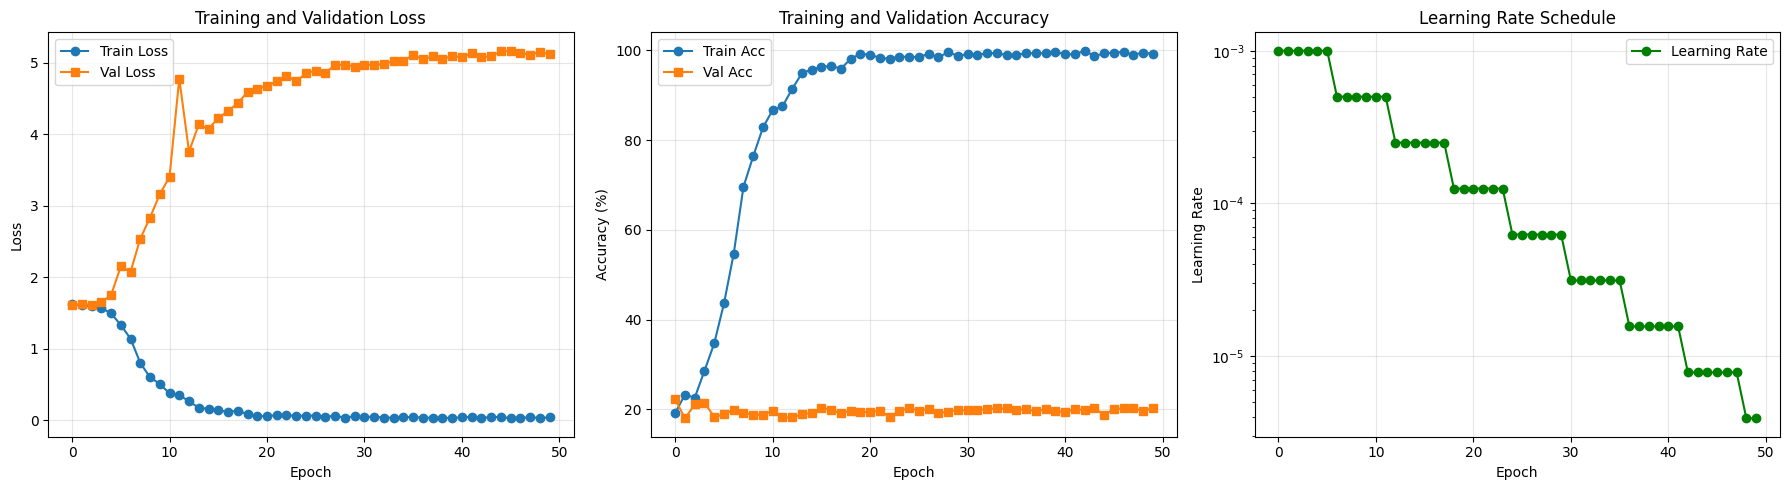

In [ ]:
# %% [markdown]
# ## 🚀 Step 6: Training Configuration

# %%
# Training hyperparameters
EPOCHS = 50
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("📋 Training Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: Adam")
print(f"  Scheduler: ReduceLROnPlateau")

# %% [markdown]
# ## 🏋️ Step 7: Training Loop

# %%
def train_epoch(model, loader, criterion, optimizer, device):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')

    for batch in pbar:
        motion_features = batch['motion_features'].to(device)
        school_labels = batch['school_label'].to(device)

        # Forward pass (school-level only for now)
        optimizer.zero_grad()
        school_output, _ = model(motion_features)

        loss = criterion(school_output, school_labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = school_output.max(1)
        total += school_labels.size(0)
        correct += predicted.eq(school_labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{running_loss/len(pbar):.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def validate_epoch(model, loader, criterion, device):
    """
    Validate for one epoch
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')

        for batch in pbar:
            motion_features = batch['motion_features'].to(device)
            school_labels = batch['school_label'].to(device)

            # Forward pass
            school_output, _ = model(motion_features)

            loss = criterion(school_output, school_labels)

            # Statistics
            running_loss += loss.item()
            _, predicted = school_output.max(1)
            total += school_labels.size(0)
            correct += predicted.eq(school_labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(school_labels.cpu().numpy())

            # Update progress bar
            pbar.set_postfix({
                'loss': f'{running_loss/len(pbar):.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

# %%
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_model_path = Path(SAVE_PATH) / 'behavior_detection_best.pth'
best_model_path.parent.mkdir(parents=True, exist_ok=True)

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 70)

    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Validate
    val_loss, val_acc, val_preds, val_labels = validate_epoch(
        model, valid_loader, criterion, device
    )

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"  Learning Rate: {current_lr:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, best_model_path)
        print(f"  ✓ Best model saved! (Val Acc: {val_acc:.2f}%)")

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time/60:.2f} minutes")
print(f"  Best validation accuracy: {best_val_acc:.2f}%")

# %% [markdown]
# ## 📊 Step 8: Visualize Training History

# %%
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate plot
axes[2].plot(history['lr'], label='Learning Rate', marker='o', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('behavior_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

✓ Loaded best model (Val Acc: 22.20%)


Validation:   0%|          | 0/63 [00:00<?, ?it/s]


TEST SET EVALUATION
Test Loss: 1.6115
Test Accuracy: 20.90%

📊 Classification Report:
              precision    recall  f1-score   support

     FEEDING     0.1765    0.0162    0.0297       185
      NORMAL     0.0000    0.0000    0.0000       192
      FRIGHT     0.0000    0.0000    0.0000       203
     HYPOXIA     0.2096    0.9810    0.3453       210
  STARVATION     0.0000    0.0000    0.0000       210

    accuracy                         0.2090      1000
   macro avg     0.0772    0.1994    0.0750      1000
weighted avg     0.0767    0.2090    0.0780      1000


 Per-Class F1 Scores:
  FEEDING: 0.0297
  NORMAL: 0.0000
  FRIGHT: 0.0000
  HYPOXIA: 0.3453
  STARVATION: 0.0000


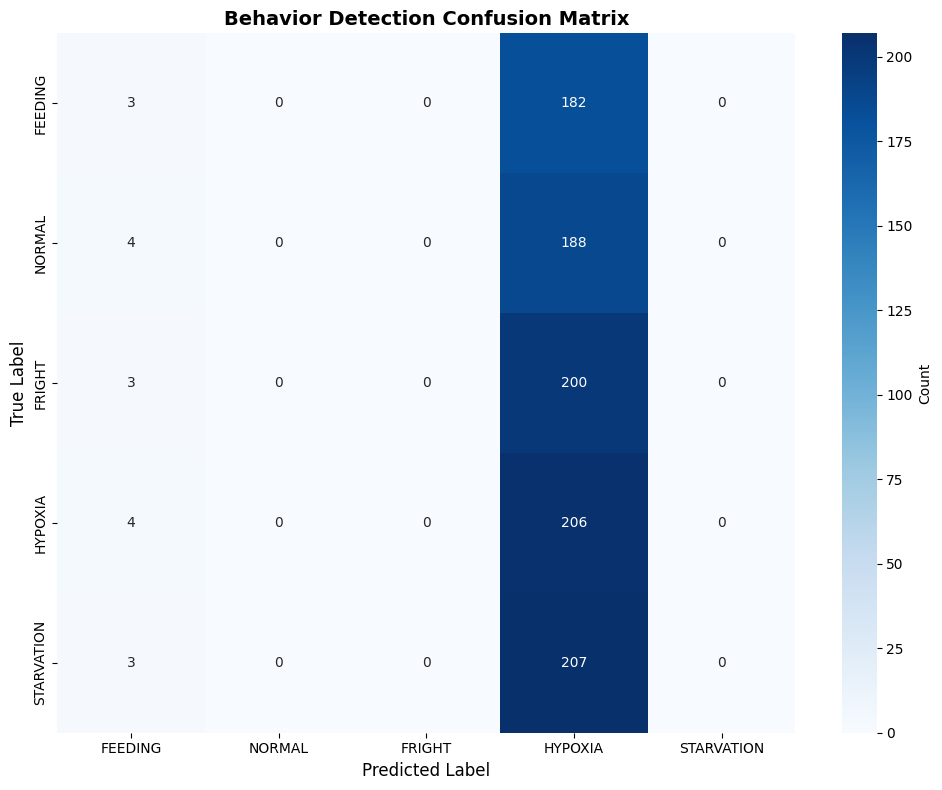

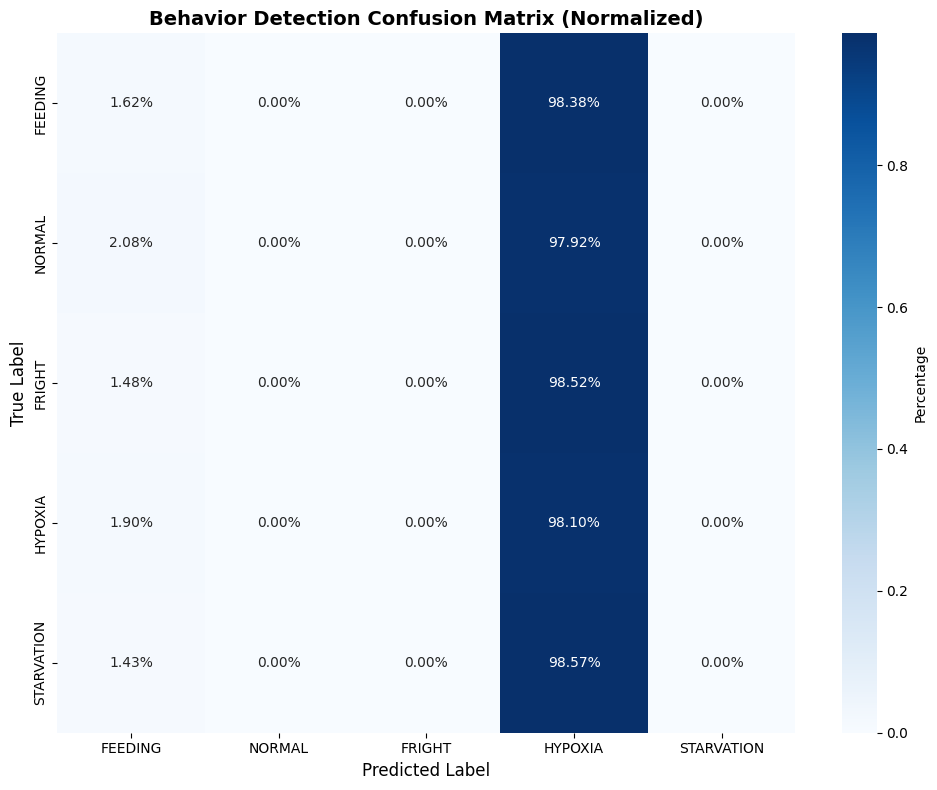

In [ ]:
# %% [markdown]
# ## 🧪 Step 9: Evaluate on Test Set

# %%
# Load best model
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model (Val Acc: {checkpoint['val_acc']:.2f}%)")

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = validate_epoch(
    model, test_loader, criterion, device
)

print("\n" + "="*70)
print("TEST SET EVALUATION")
print("="*70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification report
class_names = train_dataset.school_classes
print("\n📊 Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Calculate per-class F1 scores
f1_scores = f1_score(test_labels, test_preds, average=None)
print("\n Per-Class F1 Scores:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {f1_scores[i]:.4f}")

# %% [markdown]
# ## 📈 Step 10: Confusion Matrix

# %%
# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Behavior Detection Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('behavior_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Behavior Detection Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('behavior_confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# %% [markdown]
# ## 💾 Step 11: Save & Export Model

# %%
# Create save directory
Path(SAVE_PATH).mkdir(parents=True, exist_ok=True)

print("="*70)
print("SAVING AND EXPORTING MODEL")
print("="*70)

# 1. Save best model checkpoint
final_checkpoint = {
    'epoch': checkpoint['epoch'],
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': checkpoint['optimizer_state_dict'],
    'test_acc': test_acc,
    'val_acc': best_val_acc,
    'school_classes': class_names,
    'fish_classes': train_dataset.fish_classes,
    'model_config': {
        'motion_features': 8,
        'fish_features': 7,
        'school_classes': 5,
        'fish_classes': 5,
        'sequence_length': 30
    },
    'training_history': history
}

checkpoint_path = Path(SAVE_PATH) / 'behavior_detection_best.pth'
torch.save(final_checkpoint, checkpoint_path)
print(f"✓ Best model checkpoint saved: {checkpoint_path}")
print(f"  Size: {checkpoint_path.stat().st_size / (1024*1024):.2f} MB")

# 2. Save full model (easier to load)
full_model_path = Path(SAVE_PATH) / 'behavior_detection_full.pth'
torch.save(model, full_model_path)
print(f"✓ Full model saved: {full_model_path}")
print(f"  Size: {full_model_path.stat().st_size / (1024*1024):.2f} MB")

# 3. Save model info
model_info = {
    'model_name': 'Behavior Detection - Dual Stream',
    'model_version': '1.0',
    'created_date': time.strftime('%Y-%m-%d %H:%M:%S'),
    'architecture': 'School CNN + Per-Fish LSTM',
    'school_classes': class_names,
    'fish_classes': train_dataset.fish_classes,
    'test_accuracy': float(test_acc),
    'best_val_accuracy': float(best_val_acc),
    'total_parameters': total_params,
    'trainable_parameters': trainable_params,
    'training_epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'training_time_minutes': training_time / 60,
    'f1_scores': {
        class_names[i]: float(f1_scores[i]) for i in range(len(class_names))
    }
}

model_info_path = Path(SAVE_PATH) / 'behavior_model_info.json'
with open(model_info_path, 'w') as f:
    json.dump(model_info, f, indent=2)
print(f"✓ Model info saved: {model_info_path}")

# 4. Save training history
history_path = Path(SAVE_PATH) / 'behavior_training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"✓ Training history saved: {history_path}")

# 5. Copy to Google Drive (if on Colab)
if IN_COLAB:
    print("\n📤 Copying files to Google Drive...")
    drive_path = '/content/drive/MyDrive/marina_plus_models'
    Path(drive_path).mkdir(parents=True, exist_ok=True)

    import shutil

    files_to_copy = [
        checkpoint_path,
        full_model_path,
        model_info_path,
        history_path
    ]

    for file_path in files_to_copy:
        if file_path.exists():
            shutil.copy(str(file_path), str(Path(drive_path) / file_path.name))
            print(f"  ✓ Copied: {file_path.name}")

    # Copy plots
    plot_files = [
        'behavior_training_history.png',
        'behavior_confusion_matrix.png',
        'behavior_confusion_matrix_normalized.png'
    ]

    for plot_file in plot_files:
        if Path(plot_file).exists():
            shutil.copy(plot_file, str(Path(drive_path) / plot_file))
            print(f"  ✓ Copied: {plot_file}")

    print(f"\n✅ All files saved to Google Drive: {drive_path}")

print("\n" + "="*70)
print("MODEL EXPORT COMPLETE")
print("="*70)

